# <div style="background-color:rgba(204, 229, 255, 0.5); text-align:center; vertical-align: middle; padding:40px 0; margin-top:30px"><span style="color:rgba(0, 76, 153, 1);">PHYS 232 - Brownian Motion<span style="color:red"></span></span></div>





In [18]:
# Hide unnecessary warnings.
import warnings
warnings.filterwarnings('ignore')

# Import PHYS231.py and then run the installer function.
import PHYS231
PHYS231.Installer()

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm # used to generate a sequence of colours for plotting
import pandas as pd
import scipy.stats as sp
from scipy.optimize import curve_fit
from IPython.display import HTML as html_print
from IPython.display import display, Markdown, Latex
import uncertainties
import math
import sys
import os

# Change to the directory where this notebook file is saved
os.chdir(os.path.dirname(os.getcwd()))


In [51]:
import os
print(os.getcwd())
print(os.listdir())


/home/jovyan
['PHYS 121', '.config', '.cache', 'PHYS 231', '.ipynb_checkpoints', '.virtual_documents', '.jupyter', '.ipython', '.local', '.npm', 'PHYS232']


In [47]:
df = pd.read_csv("LatexSD2.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'LatexSD2.csv'

In [37]:
for i in df:
    df["r2"] = np.array((df["x"] - df["x"].shift(-1))**2 + (df["y"] - df["y"].shift(-1))**2)

In [38]:
df["r2a"] = df["r2"] / (0.033333 * (df.index + 1))

In [39]:
df = df[:-1]

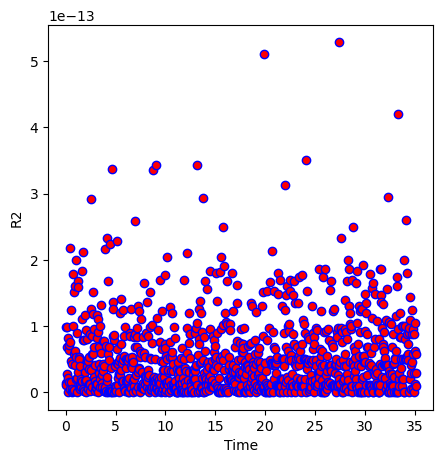

In [40]:
PHYS231.Scatter(
    xData = df["t"],
    yData = df["r2"],
    xlabel = "Time",
    ylabel = "R2",
    xUnits = "",
    yUnits = ""
);

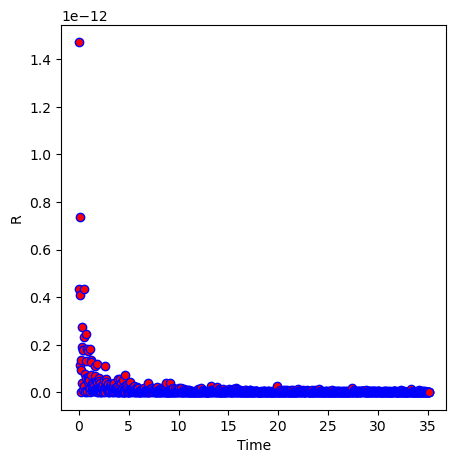

In [41]:
PHYS231.Scatter(
    xData = df["t"],
    yData = df["r2a"],
    xlabel = "Time",
    ylabel = "R",
    xUnits = "",
    yUnits = ""
);

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value
slope,$m =$,(-1.37+/-0.18)e-15
$y$-intercept,$b =$,(3.53+/-0.36)e-14


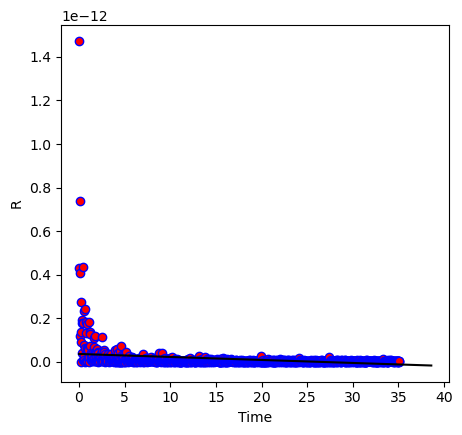

In [42]:
m, b, dm, db, fig3 = PHYS231.LinearFit(
    xData = df["t"],
    yData = df["r2a"],
    xlabel = "Time",
    ylabel = "R",
    xUnits = "",
    yUnits = ""
);

In [43]:
print(m)

-1.3743349931004319e-15


In [44]:

R = 8.314462618
T = 293.15       
eta = 0.001        
a = 0.51e-6       
na_ex = (2 * R * T) / (3 * np.pi * eta * a * np.abs(m))
err_na_exp = na_ex * (dm / m)

print(f"Calculated Slope (m): {m} {err_na_exp}")
print(f"Experimental Avogadro's Number (Na): {na_ex:.4e} +- {err_na_exp:.4e}")



Calculated Slope (m): -1.3743349931004319e-15 -9.473202459322234e+25
Experimental Avogadro's Number (Na): 7.3794e+26 +- -9.4732e+25


In [45]:

exponent = int(np.floor(np.log10(abs(na_ex))))
factor = 10**exponent


val_scaled = na_ex / factor
err_scaled = err_na_exp / factor

print(f"Experimental Na: ({val_scaled:.2f} ± {err_scaled:.2f}) × 10^{exponent} mol⁻¹")

Experimental Na: (7.38 ± -0.95) × 10^26 mol⁻¹
